# 第 0 章:PyTorch 热身

**目标**:在进入 Transformer 之前,把 PyTorch 的 6 个核心概念打通,并能独立写一个训练循环。

**使用方式**:每个小节都有 `# TODO` 的空位,请你自己填入代码再运行。不要只看,要动手敲。

**章节内容**
1. 环境验证(GPU 是否可用)
2. 张量基础(创建 / shape / reshape / view / permute)
3. 自动求导(autograd)
4. `nn.Module` 子类化
5. `Dataset` / `DataLoader`
6. 训练循环标准模板(forward → loss → backward → step → zero_grad)
7. 毕业作业:在 MNIST 上训练一个两层 MLP 到 ≥ 95% 准确率

## 1. 环境验证

先确认 PyTorch 装好、CUDA 可用。

In [2]:
import torch

print("PyTorch 版本:", torch.__version__)
print("CUDA 是否可用:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU 型号:", torch.cuda.get_device_name(0))
    print("CUDA 版本:", torch.version.cuda)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("\n使用设备:", device)

PyTorch 版本: 2.0.1+cu118
CUDA 是否可用: True
GPU 型号: NVIDIA GeForce GTX 1060 6GB
CUDA 版本: 11.8

使用设备: cuda


## 2. 张量基础

**核心要点**
- `torch.tensor(list)` / `torch.zeros` / `torch.ones` / `torch.randn` 创建张量
- `.shape`、`.dtype`、`.device` 是最常查的三个属性
- `reshape`、`view`、`permute` 区别:
  - `view` 要求内存连续;`reshape` 不要求,会自动 copy
  - `permute` 是**交换维度顺序**,不是重排元素

In [2]:
# TODO: 创建一个形状为 (2, 3, 4) 的随机张量 x,dtype 为 float32
x = torch.randn(2, 3, 4, dtype=torch.float32)

print("shape:", x.shape)
print("dtype:", x.dtype)
print("device:", x.device)
print("元素总数:", x.numel())

shape: torch.Size([2, 3, 4])
dtype: torch.float32
device: cpu
元素总数: 24


In [9]:
# TODO: 把 x 变形为 (3, 8),用 reshape 实现。观察值是否发生变化。
x_reshaped = x.reshape(3, 8)
# print("x :", x)
print("reshape 后 shape:", x_reshaped.shape)

# TODO: 把原 x 从 (2, 3, 4) 转置为 (3, 2, 4),用 permute 实现。
x_permuted = x.permute(1, 0, 2)
print("permute 后 shape:", x_permuted.shape)

# 思考:x_reshaped 和 x_permuted 的元素顺序一样吗?为什么?
# 回答：不一样。因为 reshape 只改变数据的形状，不改变数据的顺序；而 permute 会改，类似于把原来的（长宽高）变成（宽长高），达到这种效果数据必须改变顺序。

reshape 后 shape: torch.Size([3, 8])
permute 后 shape: torch.Size([3, 2, 4])


## 3. 自动求导(Autograd)

神经网络训练的根基。重要概念:
- 张量设置 `requires_grad=True` 后,其参与的所有运算会被追踪
- 调用 `loss.backward()` 反向传播
- 梯度存储在 `.grad` 属性里

例子:$y = 3x^2 + 2x$,在 $x=4$ 处的导数应为 $6x + 2 = 26$。

In [10]:
# TODO: 创建标量 x=4.0,requires_grad=True
x = torch.tensor(4.0, requires_grad=True)

# TODO: 计算 y = 3*x^2 + 2*x
y = 3 * x ** 2 + 2 * x

# TODO: 对 y 做反向传播
y.backward()

print("x.grad =", x.grad)  # 期望输出 tensor(26.)

x.grad = tensor(26.)


## 4. `nn.Module` 子类化

所有模型(包括后面我们要写的 GPT)都继承自 `nn.Module`。

**最小模板**
```python
class MyModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer = nn.Linear(10, 1)
    def forward(self, x):
        return self.layer(x)
```
- `__init__` 里定义层(它们会被自动注册为参数)
- `forward` 里写前向计算,外部用 `model(x)` 调用(等价于 `model.forward(x)`)

In [5]:
import torch.nn as nn

class SimpleMLP(nn.Module):
    def __init__(self, in_dim: int, hidden_dim: int, out_dim: int):
        super().__init__()
        # TODO: 定义两层全连接 + 一个 ReLU 激活
        self.fc1 = nn.Linear(in_dim, hidden_dim)
        self.act = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, out_dim)

    def forward(self, x):
        # TODO: 实现 x -> fc1 -> ReLU -> fc2
        x = self.fc1(x)
        x = self.act(x)
        x = self.fc2(x)
        return x

# 快速验证
model = SimpleMLP(in_dim=784, hidden_dim=128, out_dim=10)
print(model)
dummy = torch.randn(2, 784)
print("输出 shape:", model(dummy).shape)  # 期望 (2, 10)

SimpleMLP(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (act): ReLU()
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)
输出 shape: torch.Size([2, 10])


## 5. `Dataset` / `DataLoader`

训练数据永远要包装成 `Dataset`,再用 `DataLoader` 做批次、打乱、并行加载。

自定义 `Dataset` 只需实现 `__len__` 和 `__getitem__`。

In [3]:
from torch.utils.data import Dataset, DataLoader

class SquareDataset(Dataset):
    """返回 (x, x^2)。纯演示用。"""
    def __init__(self, n: int = 100):
        self.xs = torch.linspace(-1, 1, n)

    def __len__(self):
        # TODO: 返回样本数
        return len(self.xs)

    def __getitem__(self, idx):
        # TODO: 返回 (x, x^2),都是标量 tensor
        x = self.xs[idx]
        return x, x ** 2

ds = SquareDataset(n=20)
loader = DataLoader(ds, batch_size=4, shuffle=True)
for xb, yb in loader:
    print("xb:", xb, "\nyb:", yb)
    break  # 只看一批

xb: tensor([ 0.2632,  0.6842, -0.1579, -0.6842]) 
yb: tensor([0.0693, 0.4681, 0.0249, 0.4681])


## 6. 训练循环标准模板

**记住这 5 步,后面所有训练代码都是它的变体:**
```
for epoch in range(E):
    for xb, yb in loader:
        pred = model(xb)              # 1. forward
        loss = loss_fn(pred, yb)      # 2. 计算损失
        optimizer.zero_grad()         # 3. 梯度清零(非常重要!)
        loss.backward()               # 4. 反向传播
        optimizer.step()              # 5. 更新参数
```
下面是一个用 MLP 拟合 $y=x^2$ 的小例子,留给你补全。

In [6]:
import torch.optim as optim

# 一个小 MLP: 1 -> 32 -> 1
reg_model = nn.Sequential(
    nn.Linear(1, 32),
    nn.Tanh(),
    nn.Linear(32, 1),
)

optimizer = optim.AdamW(reg_model.parameters(), lr=1e-2)
loss_fn = nn.MSELoss()

# 构造数据:x 范围 [-1,1],y = x^2
xs = torch.linspace(-1, 1, 200).unsqueeze(1)  # (200, 1)
ys = xs ** 2

# TODO: 补全 5 步训练循环,训练 500 个 epoch
for epoch in range(500):
    pred = reg_model(xs)
    loss = loss_fn(pred, ys)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if (epoch + 1) % 100 == 0:
        print(f"epoch {epoch+1:3d}  loss={loss.item():.6f}")

epoch 100  loss=0.001278
epoch 200  loss=0.000613
epoch 300  loss=0.000341
epoch 400  loss=0.000202
epoch 500  loss=0.000123


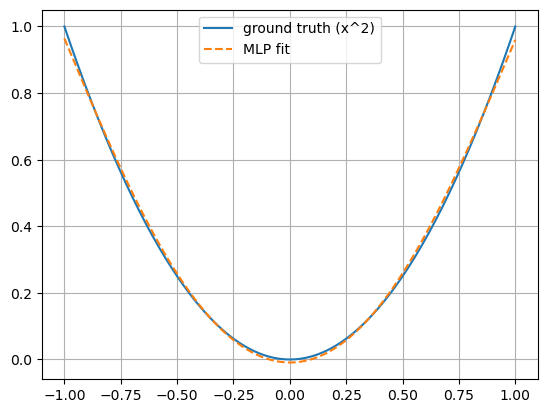

In [7]:
# 画一下拟合效果
import matplotlib.pyplot as plt

with torch.no_grad():
    pred = reg_model(xs)

plt.plot(xs.numpy(), ys.numpy(), label="ground truth (x^2)")
plt.plot(xs.numpy(), pred.numpy(), label="MLP fit", linestyle="--")
plt.legend(); plt.grid(True); plt.show()

## 7. 毕业作业:MNIST MLP

综合前面所有内容,独立训练一个 MLP 在 MNIST 上达到 **≥ 95% 测试准确率**。

**提示**
- 用 `torchvision.datasets.MNIST` 下载数据
- 图像要 flatten 成 (batch, 784)
- 分类任务用 `nn.CrossEntropyLoss`(它内置了 softmax,模型最后一层不要加 softmax)
- 先把模型 `.to(device)`,每个 batch 的数据也要 `.to(device)`
- 学习率先用 1e-3,batch_size 64,epoch 3-5 应该足够

**自测清单**(完成后逐条勾选):
- [ ] 模型和数据都在 GPU 上(打印一下 `next(model.parameters()).device`)
- [ ] 训练集 loss 持续下降
- [ ] 测试集准确率 ≥ 95%
- [ ] 不用查教程能从头写出训练循环

In [ ]:
# TODO: 实现 MNIST 训练
# 1) 准备数据:torchvision.datasets.MNIST(download=True) + DataLoader
# 2) 定义模型:例如 784 -> 256 -> 128 -> 10
# 3) 定义 optimizer(AdamW)和 loss(CrossEntropyLoss)
# 4) 训练循环:移数据到 device,forward / loss / backward / step / zero_grad
# 5) 在测试集上评估准确率

from torchvision import datasets, transforms

# 提示:transforms.ToTensor() 会把图像转成 [0,1] 的 float tensor,shape 为 (1, 28, 28)
#        你需要在 forward 里 x.view(x.size(0), -1) 变成 (batch, 784)

# 你的代码从这里开始 ...


## 章末思考题

1. 为什么每次 `backward()` 之前要 `optimizer.zero_grad()`?如果不清零会发生什么?
2. `view` 和 `reshape` 何时可以互换,何时不行?背后原因是什么?
3. 为什么分类模型最后一层不加 softmax,但推理时又需要 softmax?

能用自己的话答出来,就可以进入第 1 章。